In [124]:
import pandas as pd 
import numpy as np 

df = pd.read_excel(r"C:\Users\K9Lima\Documents\Project\Dataset\E Commerce Dataset.xlsx", sheet_name="E Comm")

print(df.shape)
df.head()

(5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


# EDA 

In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

In [126]:
# Deskripsi statistik data numerik 
print(df.describe().T) 

                              count          mean          std      min  \
CustomerID                   5630.0  52815.500000  1625.385339  50001.0   
Churn                        5630.0      0.168384     0.374240      0.0   
Tenure                       5366.0     10.189899     8.557241      0.0   
CityTier                     5630.0      1.654707     0.915389      1.0   
WarehouseToHome              5379.0     15.639896     8.531475      5.0   
HourSpendOnApp               5375.0      2.931535     0.721926      0.0   
NumberOfDeviceRegistered     5630.0      3.688988     1.023999      1.0   
SatisfactionScore            5630.0      3.066785     1.380194      1.0   
NumberOfAddress              5630.0      4.214032     2.583586      1.0   
Complain                     5630.0      0.284902     0.451408      0.0   
OrderAmountHikeFromlastYear  5365.0     15.707922     3.675485     11.0   
CouponUsed                   5374.0      1.751023     1.894621      0.0   
OrderCount               

In [154]:
# Deskripsi statistik data kategorikal
print(df.describe(include='str').T)

                     count unique           top  freq
PreferredLoginDevice  5630      2  Mobile Phone  3996
PreferredPaymentMode  5630      5    Debit Card  2314
Gender                5630      2          Male  3384
PreferedOrderCat      5630      5  Mobile Phone  2080
MaritalStatus         5630      3       Married  2986


In [128]:
# Cek duplikasi data 
print("Duplicate rows:", df.duplicated().sum())

# Drop kolom CustomerID 
df = df.drop(columns='CustomerID')

Duplicate rows: 0


In [129]:
# Mapping kategori yang namanya mirip  agar lebih konsisten
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({'Phone': 'Mobile Phone'})

df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'CC': 'Credit Card',
    'COD': 'Cash on Delivery'
})

df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})

for c in ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat']:
    print(c, '->', df[c].unique())

# Membedakan kolom numerik dan kategorikal
num_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
            'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'CouponUsed',
            'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
cat_cols = ['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode', 'Gender',
            'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'Complain']

PreferredLoginDevice -> <ArrowStringArray>
['Mobile Phone', 'Computer']
Length: 2, dtype: str
PreferredPaymentMode -> <ArrowStringArray>
['Debit Card', 'UPI', 'Credit Card', 'Cash on Delivery', 'E wallet']
Length: 5, dtype: str
PreferedOrderCat -> <ArrowStringArray>
['Laptop & Accessory', 'Mobile Phone', 'Others', 'Fashion', 'Grocery']
Length: 5, dtype: str


In [130]:
# Cek missing value 

missing = df.isnull().sum()
missing_persentase = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Jumlah data missing': missing, 'Persentase data missing (%)': missing_persentase})[missing > 0])

for c in missing.index[missing > 0]:
    flag = df[c].isnull() #true kalau missing value
    print(f"{c:30s} Churn dengan missing value (%) ={df.loc[flag, 'Churn'].mean():.3f}  "
          f"Churn tanpa missing value (%) ={df.loc[~flag, 'Churn'].mean():.3f}")

                             Jumlah data missing  Persentase data missing (%)
Tenure                                       264                         4.69
WarehouseToHome                              251                         4.46
HourSpendOnApp                               255                         4.53
OrderAmountHikeFromlastYear                  265                         4.71
CouponUsed                                   256                         4.55
OrderCount                                   258                         4.58
DaySinceLastOrder                            307                         5.45
Tenure                         Churn dengan missing value (%) =0.307  Churn tanpa missing value (%) =0.162
WarehouseToHome                Churn dengan missing value (%) =0.335  Churn tanpa missing value (%) =0.161
HourSpendOnApp                 Churn dengan missing value (%) =0.227  Churn tanpa missing value (%) =0.166
OrderAmountHikeFromlastYear    Churn dengan missing val

In [131]:
# Cek Outlier 

diagnostik = []
for c in num_cols:
    data = df[c].dropna()
    Q1, Q3 = data.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    batas_atas = Q3 + 1.5 * IQR
    batas_bawah = Q1 - 1.5 * IQR

    outlier = data[(data > batas_atas) | (data < batas_bawah)]

    diagnostik.append({
        'Fitur': c,
        'Batas Atas': round(batas_atas, 2),
        'Batas Bawah': round(batas_bawah, 2),
        'Jumlah outlier': len(outlier),
        '% outlier': round(len(outlier) / len(data) * 100, 2),
        'Nilai outlier (top 5)': sorted(outlier.tolist(), reverse=True)[:5],
        'Nilai outlier (bottom 5)': sorted(outlier.tolist())[:5],
    })

df_diagnostik = pd.DataFrame(diagnostik).sort_values('% outlier', ascending=False)
print(df_diagnostik.to_string(index=False))

                      Fitur  Batas Atas  Batas Bawah  Jumlah outlier  % outlier                    Nilai outlier (top 5)       Nilai outlier (bottom 5)
                 OrderCount        6.00        -2.00             703      13.09           [16.0, 16.0, 16.0, 16.0, 16.0]      [7.0, 7.0, 7.0, 7.0, 7.0]
                 CouponUsed        3.50        -0.50             629      11.70           [16.0, 16.0, 15.0, 14.0, 14.0]      [4.0, 4.0, 4.0, 4.0, 4.0]
             CashbackAmount      272.33        69.84             438       7.78 [324.99, 324.99, 324.73, 324.73, 324.43]     [0.0, 0.0, 0.0, 0.0, 12.0]
   NumberOfDeviceRegistered        5.50         1.50             397       7.05                          [6, 6, 6, 6, 6]                [1, 1, 1, 1, 1]
          DaySinceLastOrder       14.50        -5.50              62       1.16           [46.0, 31.0, 30.0, 18.0, 18.0] [15.0, 15.0, 15.0, 15.0, 15.0]
OrderAmountHikeFromlastYear       25.50         5.50              33       0.62         

Churn
0    4682
1     948
Name: count, dtype: int64
Churn rate: 16.84 %


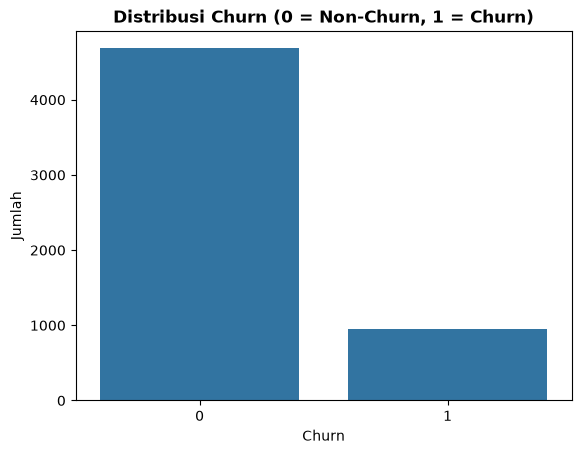

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribusi Churn
print(df['Churn'].value_counts())
print("Churn rate:", round(df['Churn'].mean() * 100, 2), "%")

sns.countplot(x='Churn', data=df)
plt.title('Distribusi Churn (0 = Non-Churn, 1 = Churn)', fontweight='bold')
plt.ylabel('Jumlah')
plt.show()

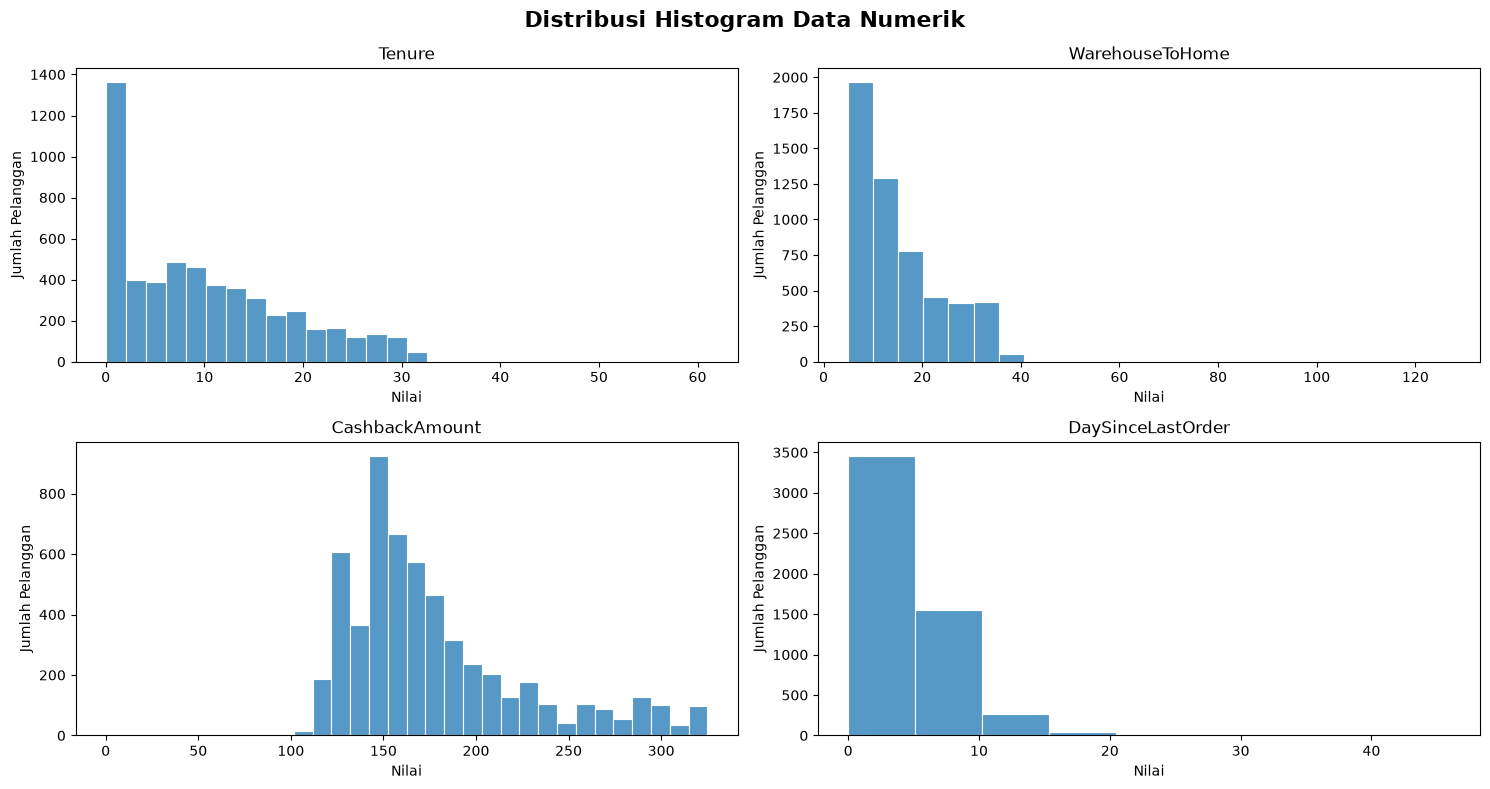

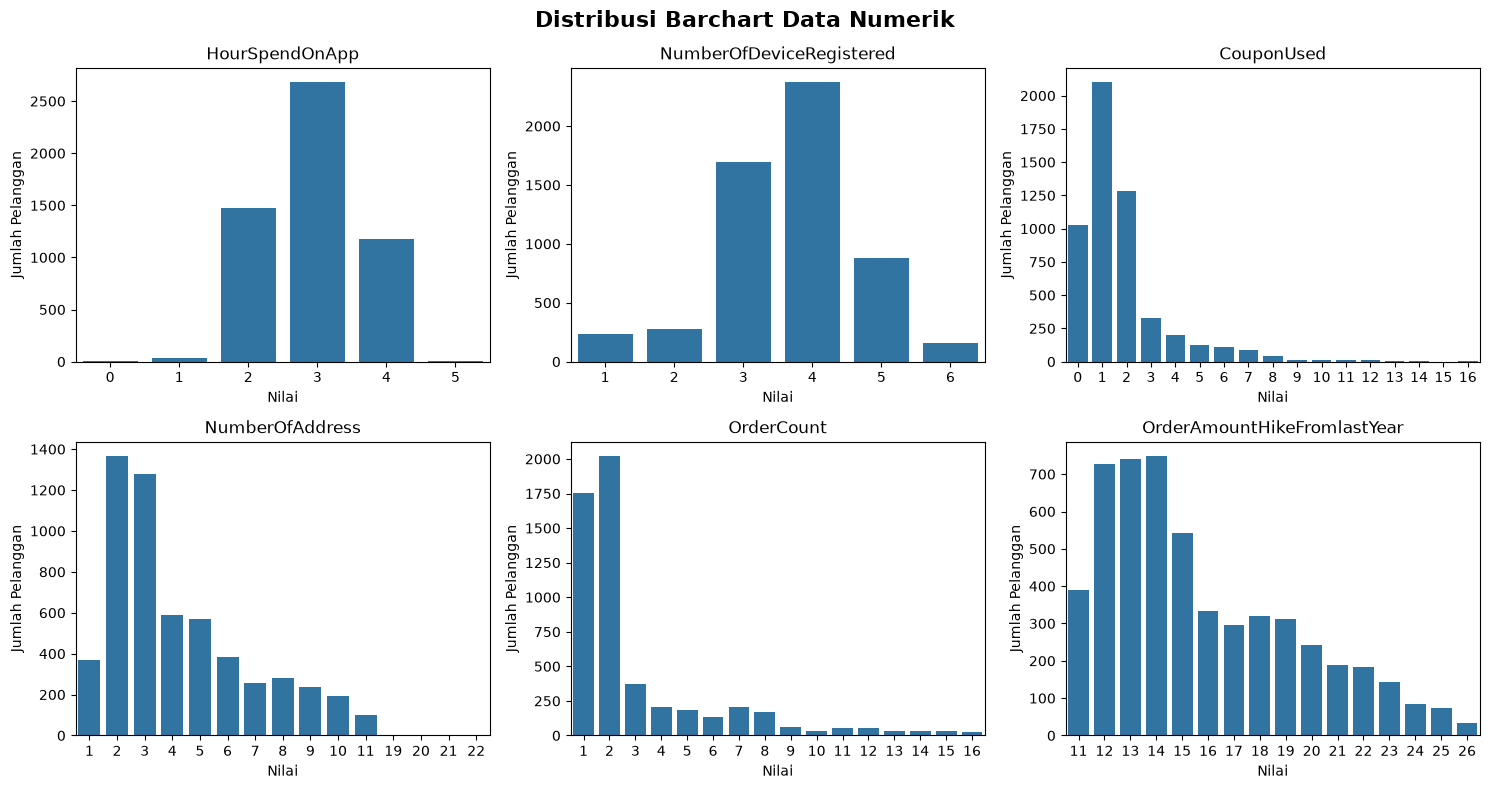

In [133]:
# Distribusi Data Numerik 

hist_settings = {
    'Tenure':            {'binwidth': 2},     # 1 batang = 2 bulan
    'WarehouseToHome':   {'binwidth': 5},     # 1 batang = 5 km
    'CashbackAmount':    {'binwidth': 10},    # 1 batang = 10 satuan
    'DaySinceLastOrder': {'binwidth': 5},  # 1 batang = 1 hari
}

# Plot histogram numerik
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, (c, kw) in zip(axes.flat, hist_settings.items()):
    sns.histplot(df[c], ax=ax, edgecolor='white', linewidth=0.8, **kw)
    ax.set_title(c)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Jumlah Pelanggan')
for ax in axes.flat[len(hist_settings):]:
    ax.set_visible(False)
fig.suptitle('Distribusi Histogram Data Numerik', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show() 

# Barchart numerik 
num_cols_bar = ['HourSpendOnApp', 'NumberOfDeviceRegistered', 'CouponUsed', 'NumberOfAddress', 'OrderCount', 'OrderAmountHikeFromlastYear']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flat, num_cols_bar):
    data = df[c].dropna().astype(int)   # buang NaN dulu, baru ke int
    sns.countplot(x=data, ax=ax)
    ax.set_title(c)
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Jumlah Pelanggan')
for ax in axes.flat[len(num_cols_bar):]:   # sembunyikan SEMUA subplot sisa
    ax.set_visible(False)
fig.suptitle('Distribusi Barchart Data Numerik', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

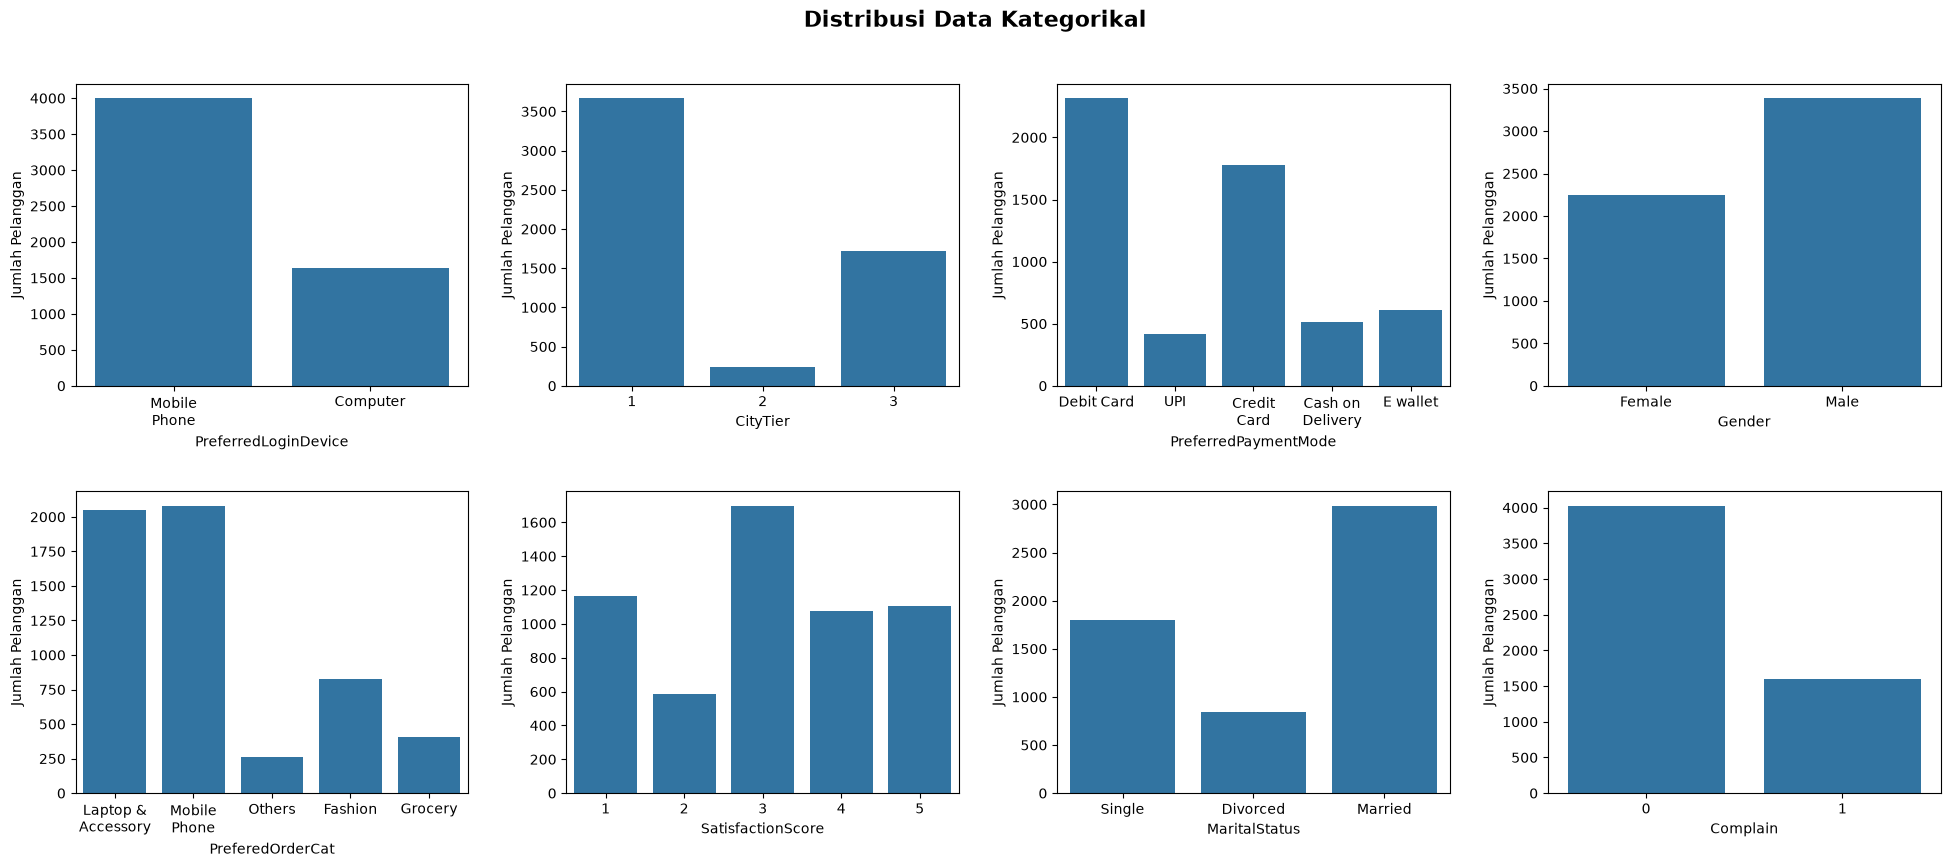

In [134]:
# Distribusi kategorikal

import textwrap

def wrap_labels(ax, width=10):
    ticks = ax.get_xticks()
    ax.set_xticks(ticks)                     
    labels = [textwrap.fill(t.get_text(), width) for t in ax.get_xticklabels()]
    ax.set_xticklabels(labels)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))   
for ax, c in zip(axes.flat, cat_cols):
    sns.countplot(x=c, data=df, ax=ax)
    wrap_labels(ax, width=10)
    ax.set_ylabel('Jumlah Pelanggan')

plt.suptitle('Distribusi Data Kategorikal', fontsize=16, fontweight='bold')
plt.tight_layout(pad=2.5)
plt.subplots_adjust(wspace=0.25, hspace=0.35)     
plt.show()

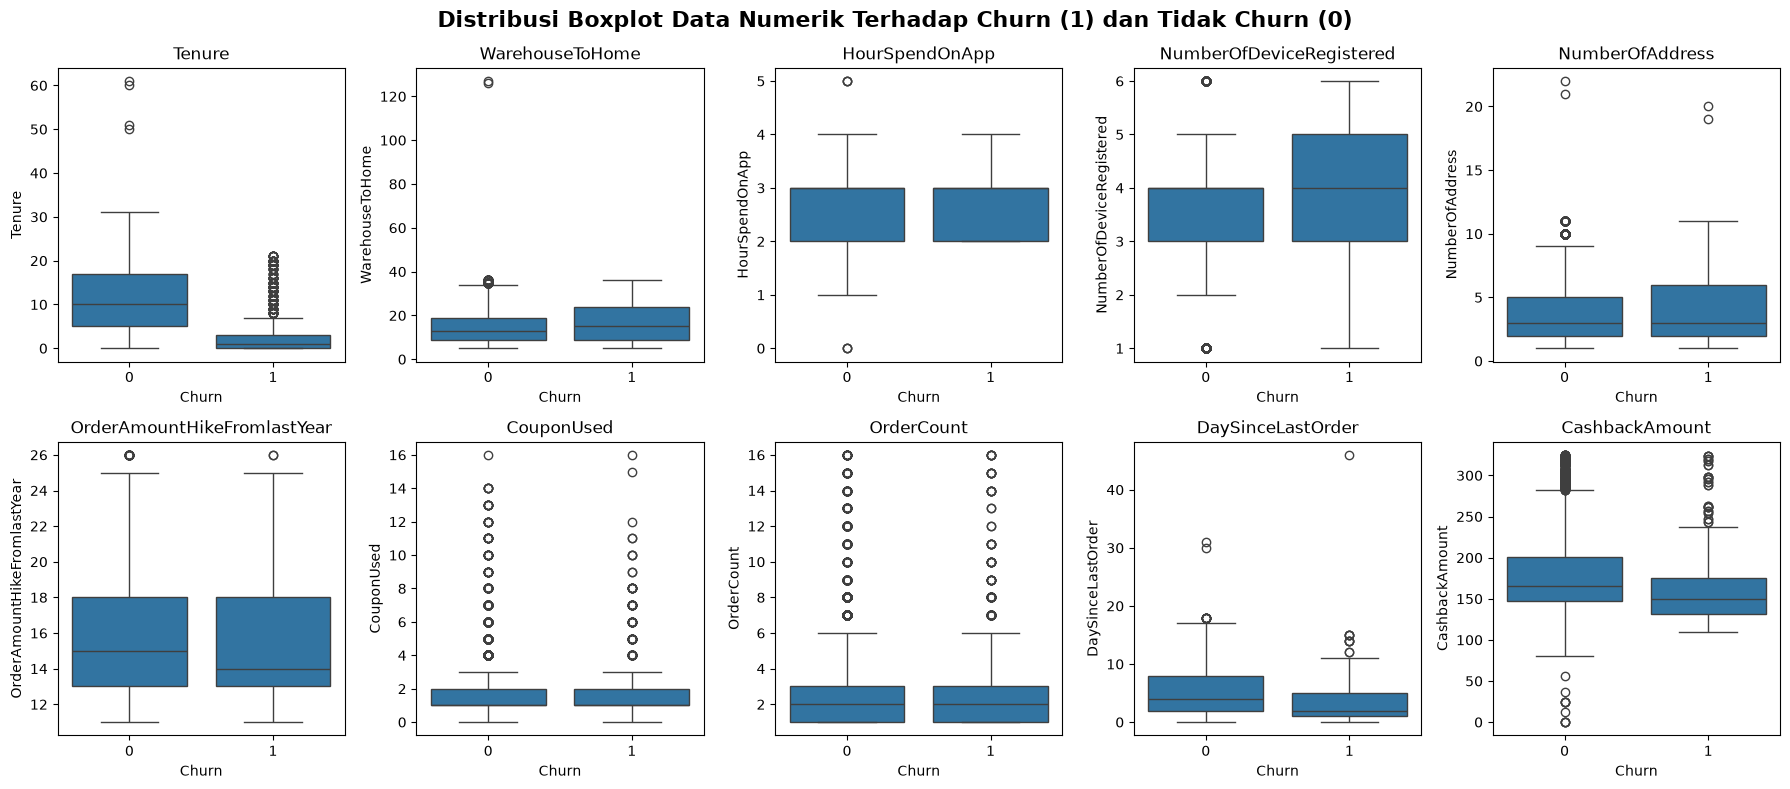

In [135]:
# Boxplot tiap fitur numerik terhadap churn

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for ax, c in zip(axes.flat, num_cols):
    sns.boxplot(x='Churn', y=c, data=df, ax=ax); ax.set_title(c)

fig.suptitle('Distribusi Boxplot Data Numerik Terhadap Churn (1) dan Tidak Churn (0)', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

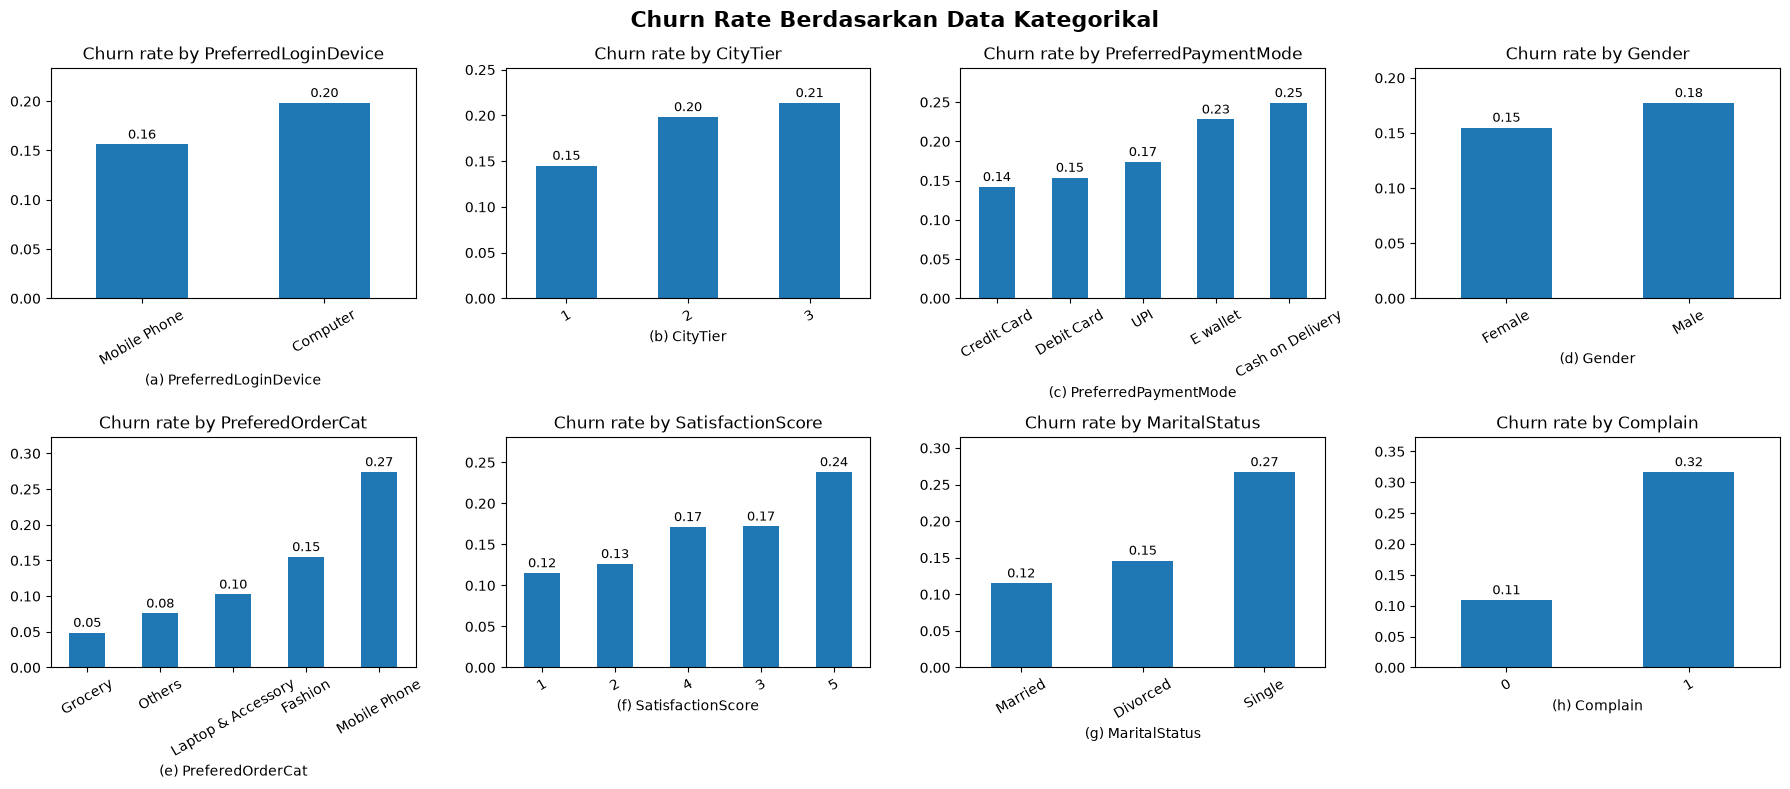

In [136]:
# Churn Rate Berdasarkan Kategori 

import string

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, (ax, c) in enumerate(zip(axes.flat, cat_cols)):
    rates = df.groupby(c)['Churn'].mean().sort_values()
    rates.plot(kind='bar', ax=ax)
    ax.set_title(f'Churn rate by {c}')
    ax.tick_params(axis='x', rotation=30)

    # beri ruang di atas agar label tidak nembus batas grafik
    ax.set_ylim(0, rates.max() * 1.18)

    # label angka di atas tiap batang
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=9,
                    xytext=(0, 2), textcoords='offset points')

    ax.set_xlabel(f'({string.ascii_lowercase[i]}) {c}')

plt.suptitle('Churn Rate Berdasarkan Data Kategorikal', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

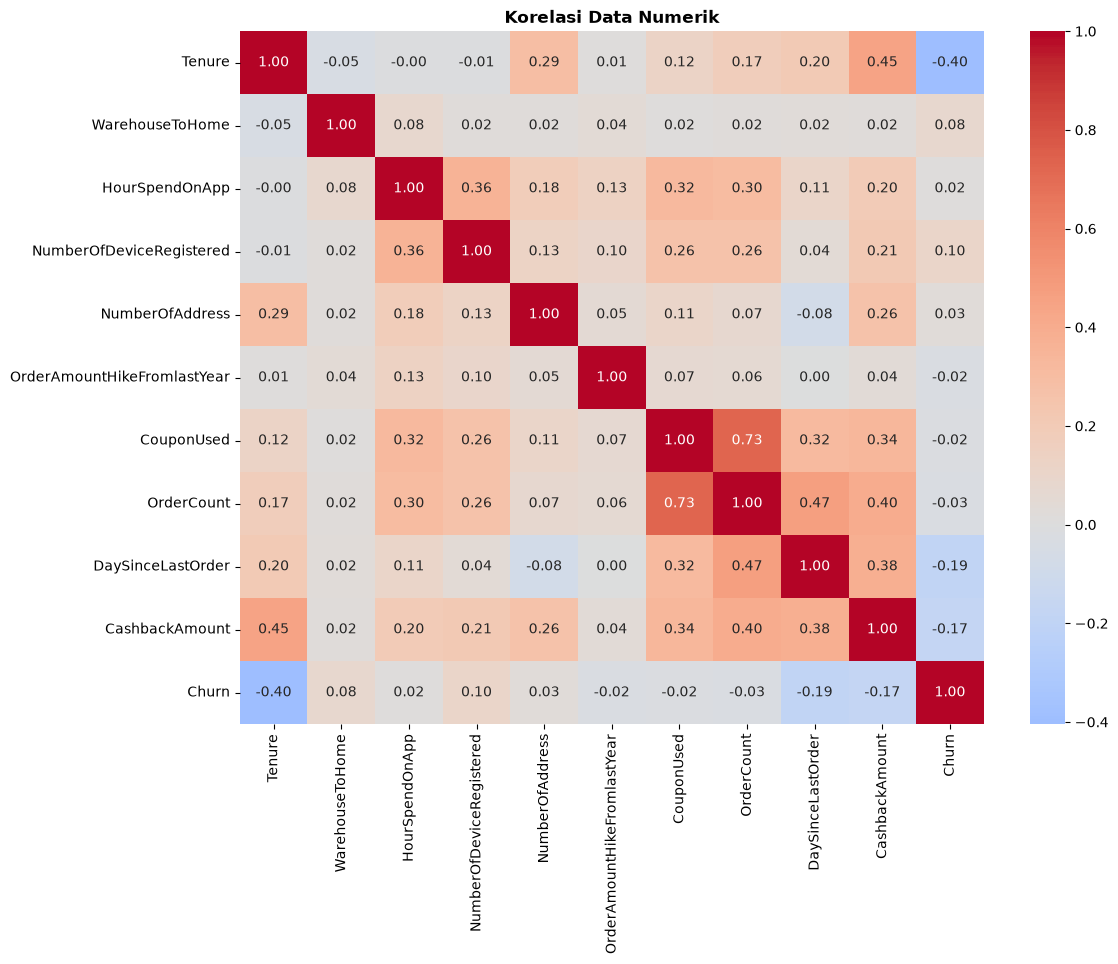

In [137]:
# Plot Korelasi Fitur Numerik 

plt.figure(figsize=(12, 9))
sns.heatmap(df[num_cols + ['Churn']].corr(method='spearman'), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Korelasi Data Numerik', fontweight='bold'); plt.show()

# Pre-Processing 

In [138]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# Split data
X = df.drop(columns='Churn')
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Transformer untuk penanganan outlier 
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, kolom):
        self.kolom = kolom
    def fit(self, X, y=None):
        Q1 = X[self.kolom].quantile(0.25)
        Q3 = X[self.kolom].quantile(0.75)
        self.batas_atas_ = Q3 + 1.5 * (Q3 - Q1)
        return self
    def transform(self, X):
        X = X.copy()
        X[self.kolom] = X[self.kolom].clip(upper=self.batas_atas_)
        return X

# Transformer untuk imputasi dan one-hot encoding
preprocessor = ColumnTransformer([
    ('numerik',    SimpleImputer(strategy='median'), num_cols),                       
    ('kategori', OneHotEncoder(drop='first', handle_unknown='ignore',
                               sparse_output=False), cat_cols),                       
])

# Model 

In [139]:
# Setup Eksperimen 

from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def buat_pipeline(model, scaled, oversample):
    """Rangkai preprocessing + model"""
    steps = [
        ('cap',  OutlierCapper('WarehouseToHome')),   
        ('prep', preprocessor),                        
    ]
    if scaled:
        steps.append(('scaler', StandardScaler()))     
    if oversample:
        steps.append(('oversampling', RandomOverSampler(random_state=42)))  
    steps.append(('model', model))
    return ImbPipeline(steps)

spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {spw:.3f}")

scale_pos_weight = 4.935


In [140]:
# Konfigurasi model baseline

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    'Logistic Regression': dict(
        est=LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
        scaled=True,  oversample=False),
    'MLP': dict(
        est=MLPClassifier(max_iter=1000, random_state=42),
        scaled=True,  oversample=True),
    'Random Forest': dict(
        est=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1),
        scaled=False, oversample=False),
    'XGBoost': dict(
        est=XGBClassifier(scale_pos_weight=spw, random_state=42, n_jobs=1),
        scaled=False, oversample=False),
    'LightGBM': dict(
        est=LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1),
        scaled=False, oversample=False),
    'CatBoost': dict(
        est=CatBoostClassifier(auto_class_weights='Balanced', random_seed=42,
                               verbose=0, thread_count=1),
        scaled=False, oversample=False),
}

# Fungsi evaluasi
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)

def plot_confusion_matrices(fitted, title_suffix=''):
    """Gambar confusion matrix 6 model."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()
    for ax, (name, pipe) in zip(axes, fitted.items()):
        y_pred = pipe.predict(X_test)              # pipeline urus preprocessing sendiri
        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=['Non-Churn', 'Churn']).plot(
            ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(name)
    fig.suptitle(f'Confusion Matrix {title_suffix}', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

def print_reports(fitted, title_suffix=''):
    """Classification report 6 model untuk satu konfigurasi."""
    print(f"\n{'='*62}")
    print(f"CLASSIFICATION REPORT {title_suffix}")
    print('='*62)
    for name, pipe in fitted.items():
        y_pred = pipe.predict(X_test)
        print(f"\n--- {name} ---")
        print(classification_report(y_test, y_pred,
                                    target_names=['Non-Churn', 'Churn'], digits=4))

In [141]:
# Loop Baseline

from sklearn.metrics import (average_precision_score, recall_score,
                             precision_score, f1_score)

fitted_baseline = {}
rows = []
for name, cfg in models.items():
    pipe = buat_pipeline(cfg['est'], cfg['scaled'], cfg['oversample'])   

    cv_prauc = cross_val_score(pipe, X_train, y_train, cv=cv,            
                               scoring='average_precision').mean()

    pipe.fit(X_train, y_train)
    fitted_baseline[name] = pipe                                         

    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    rows.append({
        'Model':      name,
        'CV_PRAUC':   cv_prauc,
        'Test_PRAUC': average_precision_score(y_test, y_proba),
        'Recall':     recall_score(y_test, y_pred),
        'Precision':  precision_score(y_test, y_pred),
        'F1-Score':   f1_score(y_test, y_pred),
    })

results = (pd.DataFrame(rows).set_index('Model')
           .sort_values('CV_PRAUC', ascending=False).round(4))
print(results)

                     CV_PRAUC  Test_PRAUC  Recall  Precision  F1-Score
Model                                                                 
Random Forest          0.9250      0.9664  0.9225     0.9291    0.9258
MLP                    0.9205      0.9751  0.9261     0.9634    0.9443
XGBoost                0.9157      0.9663  0.9296     0.9362    0.9329
LightGBM               0.9129      0.9520  0.9261     0.8376    0.8796
CatBoost               0.9046      0.9558  0.9437     0.8349    0.8860
Logistic Regression    0.6976      0.6880  0.8310     0.4461    0.5806


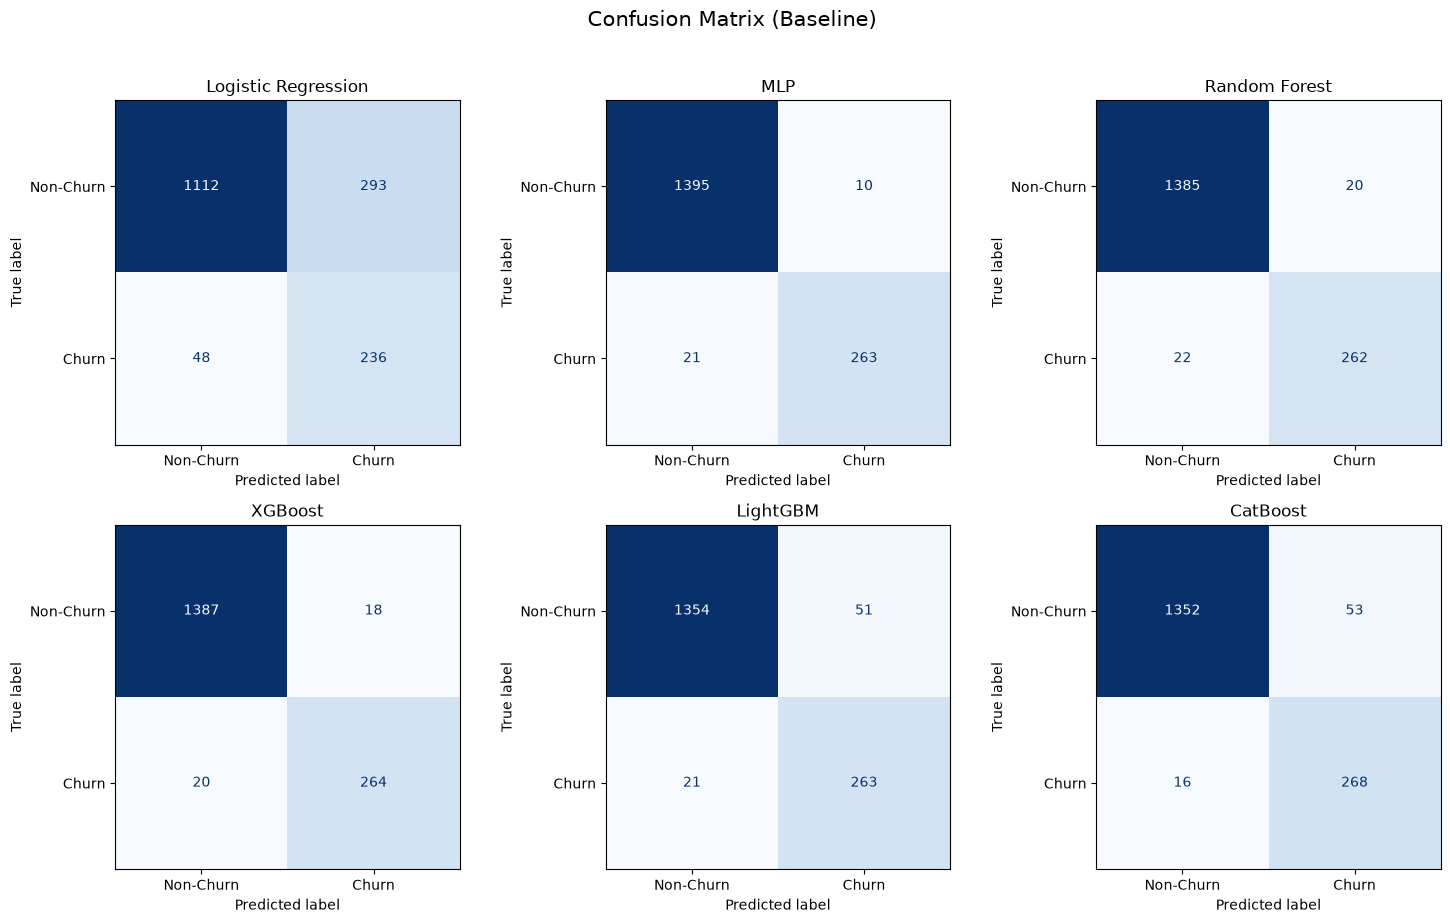


CLASSIFICATION REPORT (Baseline)

--- Logistic Regression ---
              precision    recall  f1-score   support

   Non-Churn     0.9586    0.7915    0.8671      1405
       Churn     0.4461    0.8310    0.5806       284

    accuracy                         0.7981      1689
   macro avg     0.7024    0.8112    0.7238      1689
weighted avg     0.8724    0.7981    0.8189      1689


--- MLP ---
              precision    recall  f1-score   support

   Non-Churn     0.9852    0.9929    0.9890      1405
       Churn     0.9634    0.9261    0.9443       284

    accuracy                         0.9816      1689
   macro avg     0.9743    0.9595    0.9667      1689
weighted avg     0.9815    0.9816    0.9815      1689


--- Random Forest ---
              precision    recall  f1-score   support

   Non-Churn     0.9844    0.9858    0.9851      1405
       Churn     0.9291    0.9225    0.9258       284

    accuracy                         0.9751      1689
   macro avg     0.9567    0.

In [142]:
# Visualisasi confusion matrix dan classification report

plot_confusion_matrices(fitted_baseline, '(Baseline)')
print_reports(fitted_baseline, '(Baseline)')

Tuning Hyperparameter 

In [ ]:
# Konfigurasi hyperparameter tuning

search_space = {
    'Logistic Regression': dict(
        est=LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42),
        params={'model__C':[0.01, 0.1, 1, 10, 100]},
        scaled=True,  oversample=False),
    'MLP': dict(
        est=MLPClassifier(max_iter=1000, random_state=42),
        params={'model__hidden_layer_sizes':[(64,),(100,),(128,),(64,32),(128,64)],
                'model__alpha':[0.0001, 0.001, 0.01],
                'model__learning_rate_init':[0.001, 0.01],
                'model__activation':['relu','tanh']},
        scaled=True,  oversample=True),
    'Random Forest': dict(
        est=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=1),
        params={'model__n_estimators':[100, 200, 400, 600],
                'model__max_depth':[None, 10, 20, 30],
                'model__min_samples_split':[2, 5, 10],
                'model__max_features':['sqrt','log2']},
        scaled=False, oversample=False),
    'XGBoost': dict(
        est=XGBClassifier(scale_pos_weight=spw, random_state=42, n_jobs=1),
        params={'model__n_estimators':[100, 200, 400, 600],
                'model__max_depth':[3, 6, 9],
                'model__learning_rate':[0.03, 0.05, 0.1, 0.3],
                'model__subsample':[0.8, 1.0],
                'model__colsample_bytree':[0.8, 1.0]},
        scaled=False, oversample=False),
    'LightGBM': dict(
        est=LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1),
        params={'model__n_estimators':[100, 200, 400, 600],
                'model__num_leaves':[31, 63, 127],
                'model__learning_rate':[0.03, 0.05, 0.1],
                'model__subsample':[0.8, 1.0],          
                'model__subsample_freq':[1],            
                'model__min_child_samples':[10, 20, 40]},  
        scaled=False, oversample=False),
    'CatBoost': dict(
        est=CatBoostClassifier(auto_class_weights='Balanced', random_seed=42,
                               verbose=0, thread_count=1),
        params={'model__iterations':[200, 400, 600, 1000],
                'model__depth':[4, 6, 8],
                'model__l2_leaf_reg':[1, 3, 5],
                'model__learning_rate':[0.01, 0.03, 0.05, 0.1]},
        scaled=False, oversample=False),
}

N_JOBS_SEARCH = -1

GridSearchCV

In [ ]:
# GridSearchCV

from sklearn.model_selection import GridSearchCV

tuned_grid = {}
rows_grid = []
for name, cfg in search_space.items():
    pipe = buat_pipeline(cfg['est'], cfg['scaled'], cfg['oversample'])   

    gs = GridSearchCV(pipe, cfg['params'],
                      scoring='average_precision', cv=cv,
                      n_jobs=N_JOBS_SEARCH, error_score='raise')
    gs.fit(X_train, y_train)                                            
    tuned_grid[name] = gs.best_estimator_                              

    y_pred  = gs.predict(X_test)
    y_proba = gs.predict_proba(X_test)[:, 1]
    rows_grid.append({
        'Model':      name,
        'CV_PRAUC':   gs.best_score_,
        'Test_PRAUC': average_precision_score(y_test, y_proba),
        'Recall':     recall_score(y_test, y_pred),
        'Precision':  precision_score(y_test, y_pred),
        'F1-Score':   f1_score(y_test, y_pred),
    })
    print(f"{name:22s} CV={gs.best_score_:.4f} | best={gs.best_params_}")

results_grid = (pd.DataFrame(rows_grid).set_index('Model')
                .sort_values('CV_PRAUC', ascending=False).round(4))
print("\n=== HASIL GRIDSEARCH ===")
print(results_grid)

Logistic Regression    CV=0.7056 | best={'model__C': 0.01}
MLP                    CV=0.9636 | best={'model__activation': 'tanh', 'model__alpha': 0.01, 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': 0.01}
Random Forest          CV=0.9307 | best={'model__max_depth': 20, 'model__max_features': 'log2', 'model__min_samples_split': 2, 'model__n_estimators': 600}
XGBoost                CV=0.9287 | best={'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 9, 'model__n_estimators': 600, 'model__subsample': 0.8}
LightGBM               CV=0.9455 | best={'model__learning_rate': 0.05, 'model__min_child_samples': 20, 'model__n_estimators': 600, 'model__num_leaves': 127, 'model__subsample': 1.0, 'model__subsample_freq': 1}
CatBoost               CV=0.9502 | best={'model__depth': 8, 'model__iterations': 1000, 'model__l2_leaf_reg': 1, 'model__learning_rate': 0.05}

=== HASIL GRIDSEARCH ===
                     CV_PRAUC  Test_PRAUC  Recall  Precision  

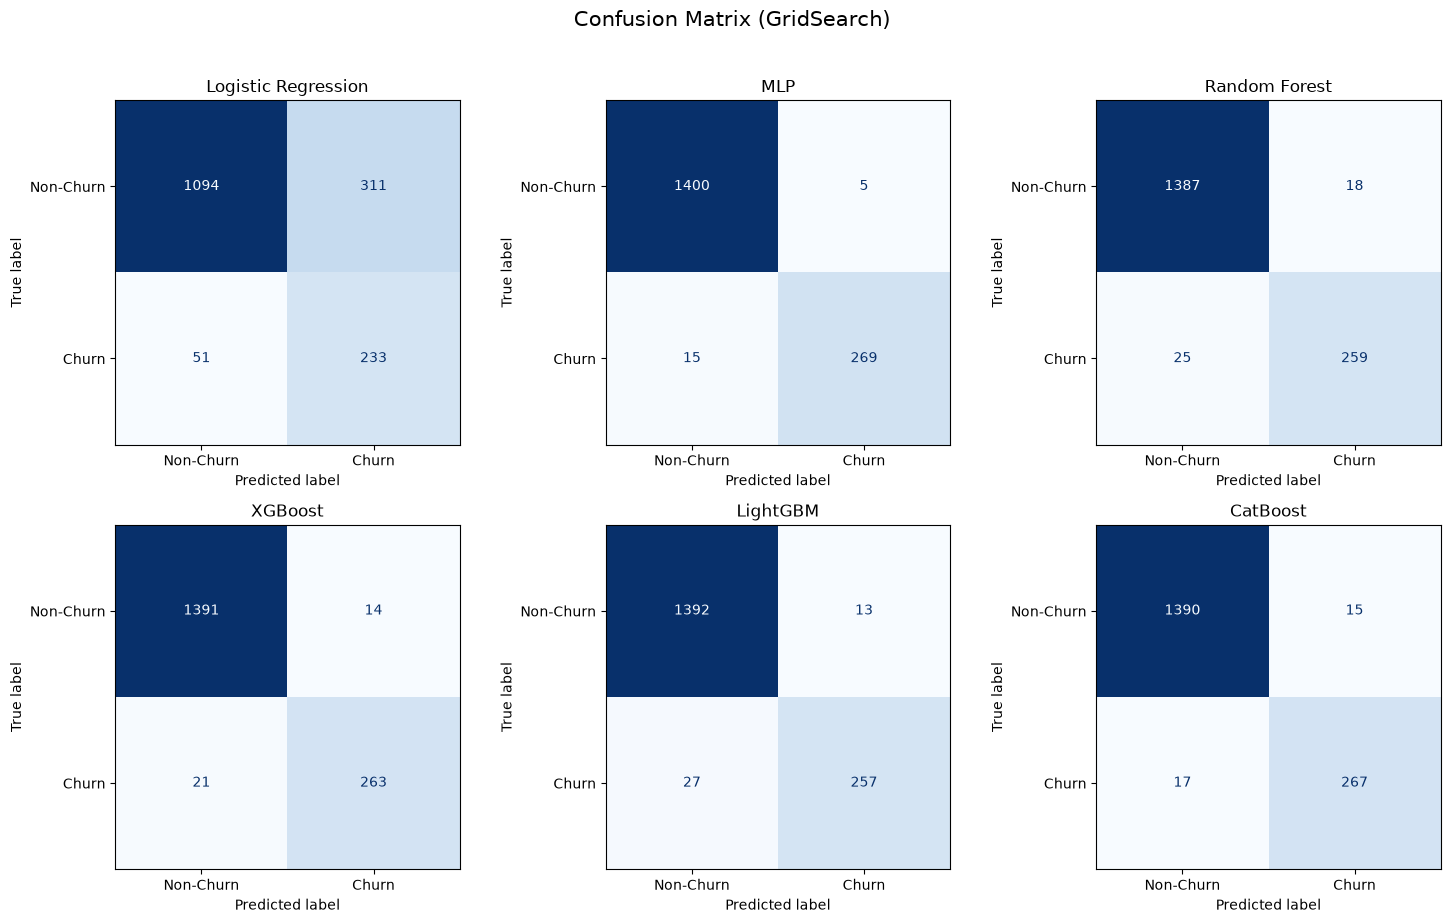


CLASSIFICATION REPORT (GridSearch)

--- Logistic Regression ---
              precision    recall  f1-score   support

   Non-Churn     0.9555    0.7786    0.8580      1405
       Churn     0.4283    0.8204    0.5628       284

    accuracy                         0.7857      1689
   macro avg     0.6919    0.7995    0.7104      1689
weighted avg     0.8668    0.7857    0.8084      1689


--- MLP ---
              precision    recall  f1-score   support

   Non-Churn     0.9894    0.9964    0.9929      1405
       Churn     0.9818    0.9472    0.9642       284

    accuracy                         0.9882      1689
   macro avg     0.9856    0.9718    0.9785      1689
weighted avg     0.9881    0.9882    0.9881      1689


--- Random Forest ---
              precision    recall  f1-score   support

   Non-Churn     0.9823    0.9872    0.9847      1405
       Churn     0.9350    0.9120    0.9234       284

    accuracy                         0.9745      1689
   macro avg     0.9587    

In [145]:
# Visualisasi confusion matrix dan classification report
plot_confusion_matrices(tuned_grid, '(GridSearch)')
print_reports(tuned_grid, '(GridSearch)')

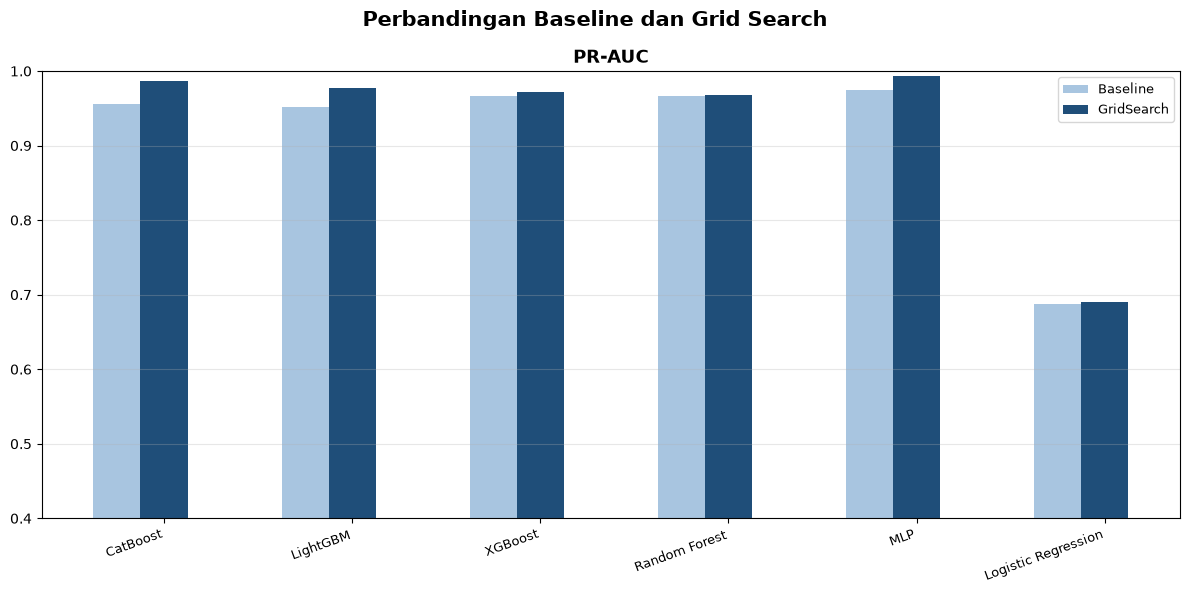

In [146]:
# Plot Perbandingan 2 konfigurasi per-model & metrik

import matplotlib.pyplot as plt
import numpy as np

def standardize(df):
    """Perbandingan baseline dan grid search pada metrik PR-AUC."""
    return pd.DataFrame({
        'PR-AUC':    df['Test_PRAUC'],
    })

configs = {
    'Baseline':     standardize(results),
    'GridSearch':   standardize(results_grid),
}

metrics = ['PR-AUC']
model_order = ['CatBoost','LightGBM','XGBoost','Random Forest','MLP','Logistic Regression']

fig, axes = plt.subplots(1, 1, figsize=(12, 6))
axes = np.atleast_1d(axes)
x = np.arange(len(model_order)); w = 0.25
colors = {'Baseline':'#a8c5e0', 'GridSearch':'#1f4e79'}

for ax, metric in zip(axes, metrics):
    for i, (cfgname, dfc) in enumerate(configs.items()):
        vals = dfc.loc[model_order, metric].values
        ax.bar(x + (i-1)*w, vals, w, label=cfgname, color=colors[cfgname])
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(model_order, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0.4, 1.0); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)

fig.suptitle('Perbandingan Baseline dan Grid Search', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## SHAP 

PermutationExplainer explainer: 1690it [03:24,  7.89it/s]                          


(1689, 29)
base value: 0.1105


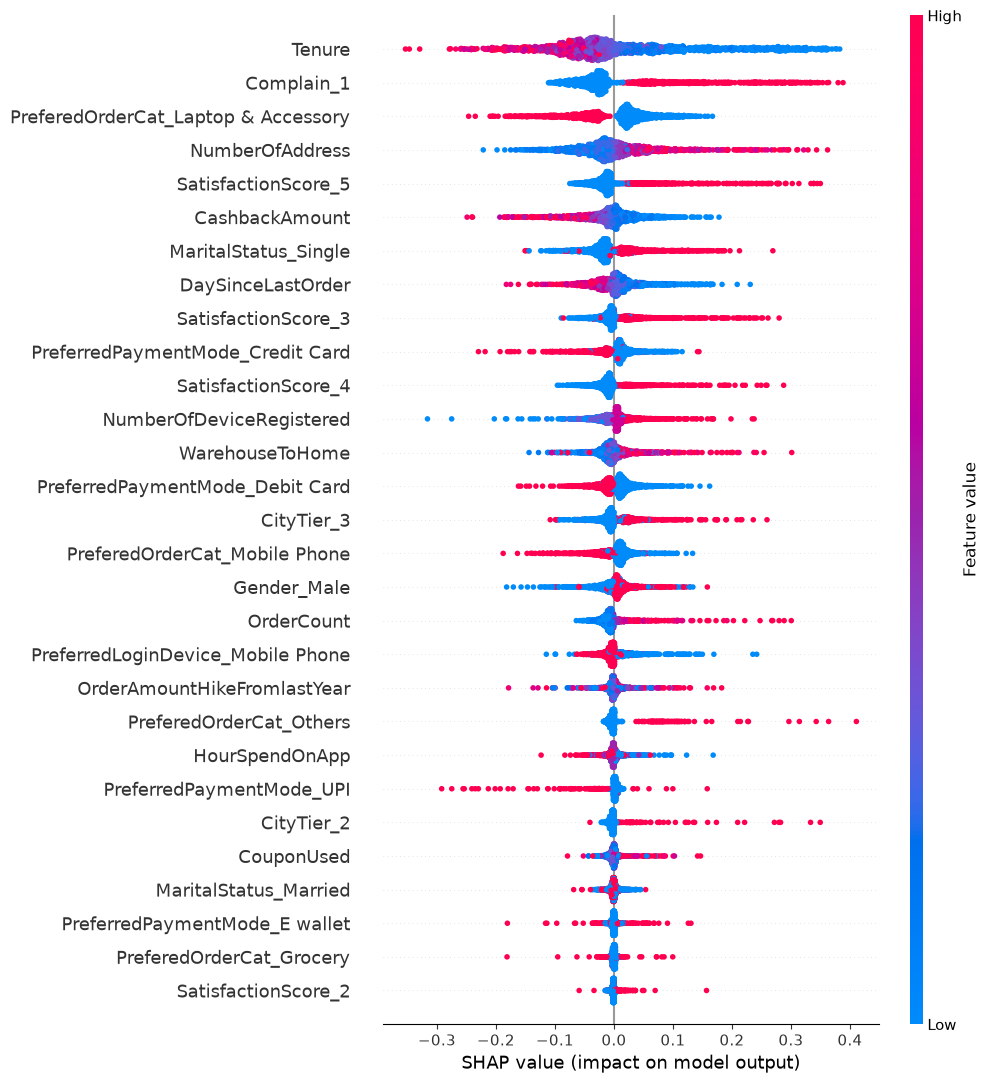

In [147]:
import shap
import numpy as np
import pandas as pd
import joblib

mlp_pipe = tuned_grid['MLP']

# Memisahkan tahap preprocessing dari model di dalam pipeline
cap_step    = mlp_pipe.named_steps['cap']       # penanganan outlier
encode_step = mlp_pipe.named_steps['prep']      # imputasi + one-hot encoding
scaler_step = mlp_pipe.named_steps['scaler']    # scaling
mlp_only    = mlp_pipe.named_steps['model']     # model MLP

# Mengubah data mentah menjadi 29 kolom terskala, sesuai input yang diterima model
def transformasi_fitur(X_mentah):
    X = cap_step.transform(X_mentah)     # penanganan outlier
    X = encode_step.transform(X)         # imputasi + one-hot encoding
    X = scaler_step.transform(X)         # scaling
    return X

# Mengambil nama 29 fitur, tanpa awalan 'angka__' / 'kategori__' dari ColumnTransformer
nama_fitur = [n.split('__', 1)[1] for n in encode_step.get_feature_names_out()]

# Menyiapkan data untuk SHAP
X_test_sc_df  = pd.DataFrame(transformasi_fitur(X_test),  columns=nama_fitur)
X_train_sc_df = pd.DataFrame(transformasi_fitur(X_train), columns=nama_fitur)

# SHAP menjelaskan model MLP secara langsung, dengan input yang sudah terskala
def f_churn(x):
    return mlp_only.predict_proba(np.asarray(x))[:, 1]

# Background dataset sebagai acuan nilai fitur saat dianggap "tidak diketahui"
bg = shap.sample(X_train_sc_df, 100, random_state=42)
explainer = shap.Explainer(f_churn, bg)
sv = explainer(X_test_sc_df)

# Menyimpan hasil perhitungan SHAP
joblib.dump({'values': sv.values,
             'base_values': sv.base_values,
             'data': sv.data,
             'feature_names': nama_fitur}, 'shap_mlp.pkl')

print(sv.shape)                 # harusnya (1689, 29)
print(f"base value: {sv.base_values[0]:.4f}")

# Beeswarm plot
shap.plots.beeswarm(sv, max_display=29)

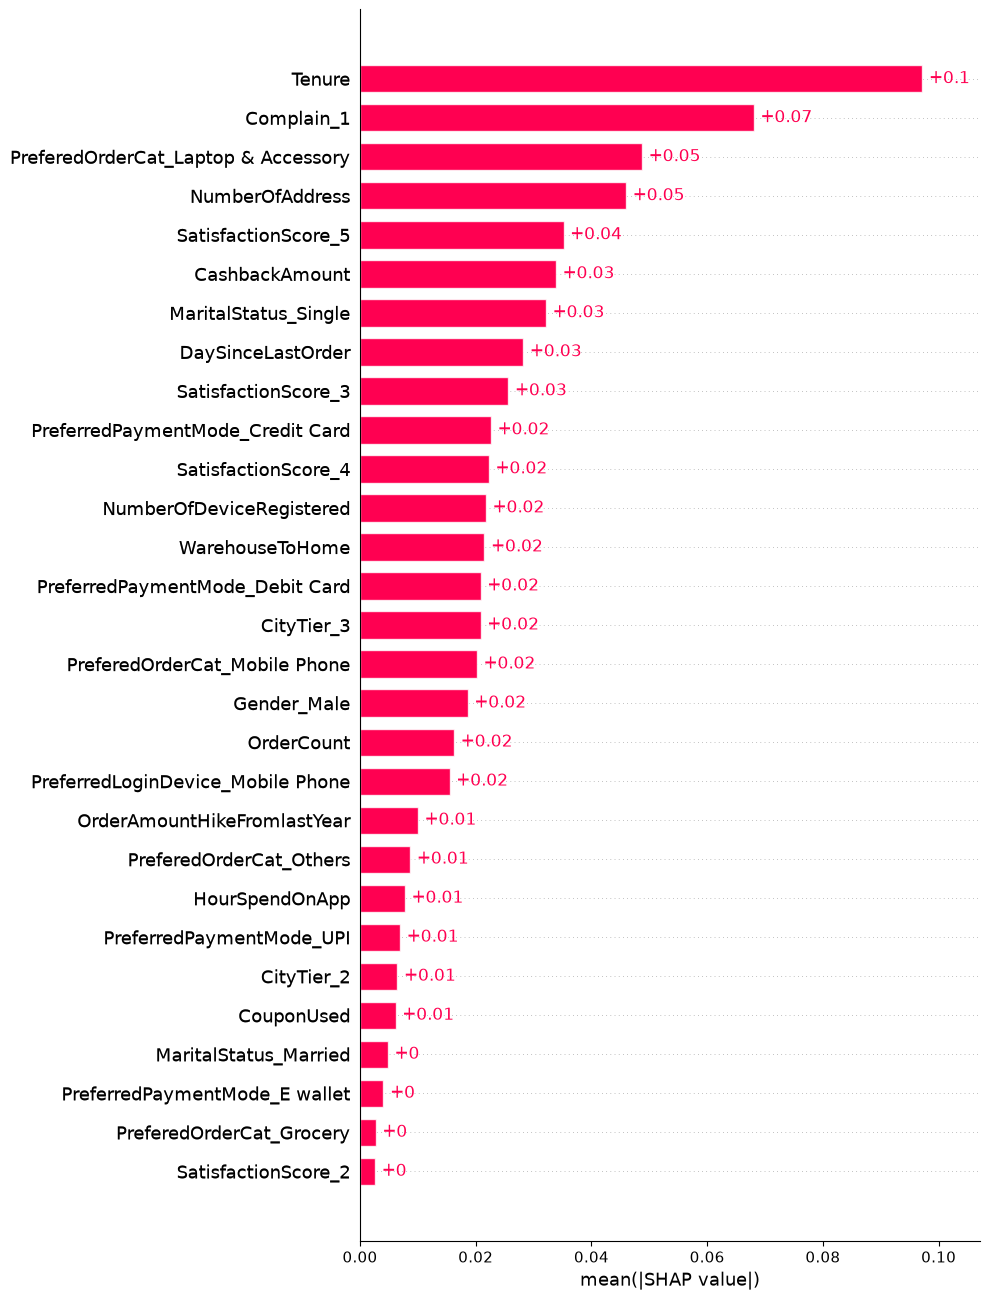

                                  Fitur  Mean |SHAP value|
1                                Tenure           0.097182
2                            Complain_1           0.068054
3   PreferedOrderCat_Laptop & Accessory           0.048740
4                       NumberOfAddress           0.045979
5                   SatisfactionScore_5           0.035168
6                        CashbackAmount           0.033863
7                  MaritalStatus_Single           0.032136
8                     DaySinceLastOrder           0.028204
9                   SatisfactionScore_3           0.025631
10     PreferredPaymentMode_Credit Card           0.022633
11                  SatisfactionScore_4           0.022262
12             NumberOfDeviceRegistered           0.021756
13                      WarehouseToHome           0.021497
14      PreferredPaymentMode_Debit Card           0.020836
15                           CityTier_3           0.020836
16        PreferedOrderCat_Mobile Phone           0.0201

In [ ]:
# Feature Importance 

shap.plots.bar(sv, max_display=29)

mean_abs_shap = np.abs(sv.values).mean(axis=0)   # rata-rata absolut per kolom fitur

df_importance = pd.DataFrame({
    'Fitur': sv.feature_names,
    'Mean |SHAP value|': mean_abs_shap
}).sort_values('Mean |SHAP value|', ascending=False).reset_index(drop=True)

df_importance.index += 1   
print(df_importance.to_string())

Pelanggan terpilih: index 150, probabilitas churn 0.0000, aktual Non-Churn

=== Pelanggan acak — probabilitas 0.0000002, aktual Non-Churn ===


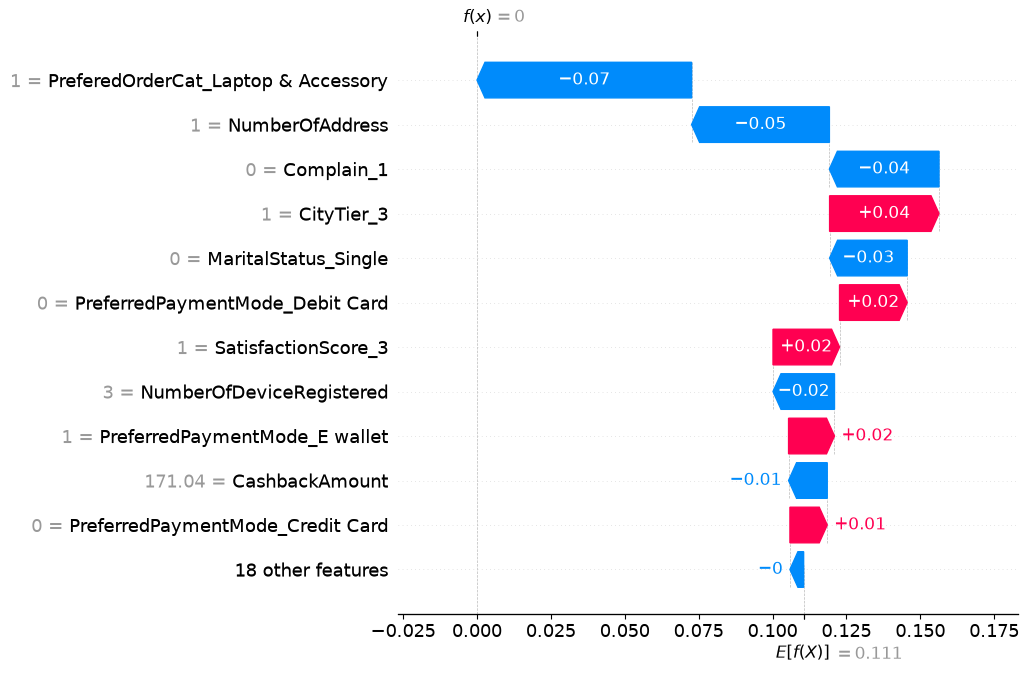

In [149]:
# Waterfall plot (pelanggan churn)

proba = f_churn(X_test_sc_df)

# Mengambil satu pelanggan secara acak 
rng = np.random.default_rng(42)
i_acak = int(rng.integers(0, len(proba)))

print(f"Pelanggan terpilih: index {i_acak}, "
      f"probabilitas churn {proba[i_acak]:.4f}, "
      f"aktual {'Churn' if y_test.iloc[i_acak]==1 else 'Non-Churn'}")

for i, label in [(i_acak, 'Pelanggan acak')]:
    print(f"\n=== {label} — probabilitas {proba[i]:.7f}, "
          f"aktual {'Churn' if y_test.iloc[i]==1 else 'Non-Churn'} ===")

    sv_asli = sv[i]
    sv_asli.data = X_test_original.iloc[i].values
    shap.plots.waterfall(sv_asli, max_display=12)

Pelanggan terpilih: index 548, probabilitas churn 0.9962, aktual Churn

=== Pelanggan acak — probabilitas 0.9961568, aktual Churn ===


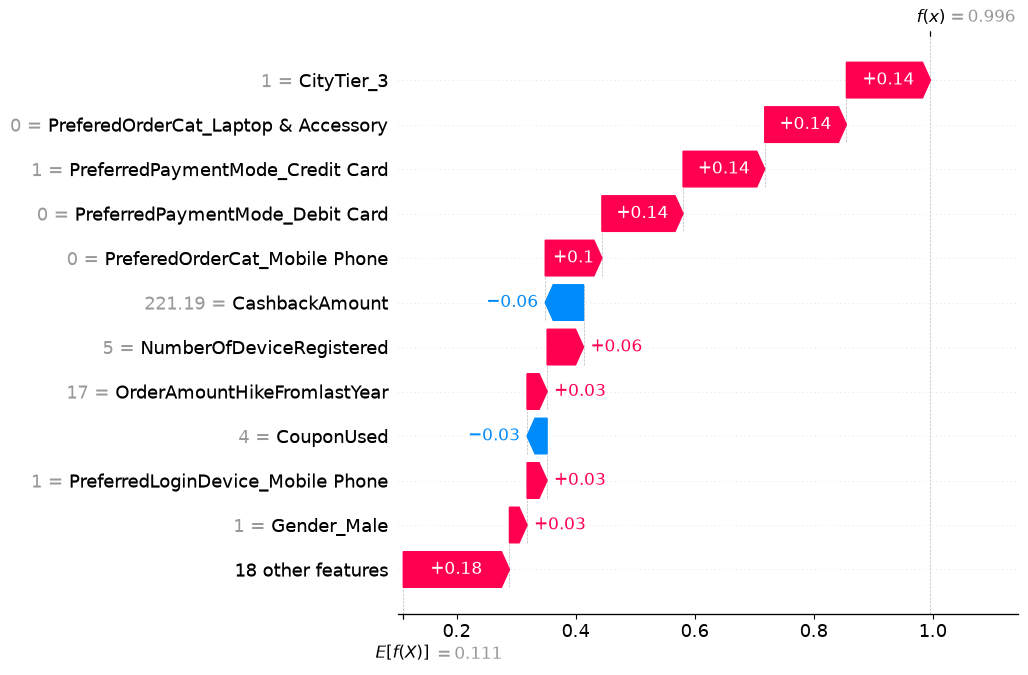

In [ ]:
# Waterfall plot (pelanggan non-churn)

proba = f_churn(X_test_sc_df)

# Mengambil satu pelanggan secara acak 
rng = np.random.default_rng(120)
i_acak = int(rng.integers(0, len(proba)))

print(f"Pelanggan terpilih: index {i_acak}, "
      f"probabilitas churn {proba[i_acak]:.4f}, "
      f"aktual {'Churn' if y_test.iloc[i_acak]==1 else 'Non-Churn'}")

for i, label in [(i_acak, 'Pelanggan acak')]:
    print(f"\n=== {label} — probabilitas {proba[i]:.7f}, "
          f"aktual {'Churn' if y_test.iloc[i]==1 else 'Non-Churn'} ===")

    sv_asli = sv[i]
    sv_asli.data = X_test_original.iloc[i].values
    shap.plots.waterfall(sv_asli, max_display=12)

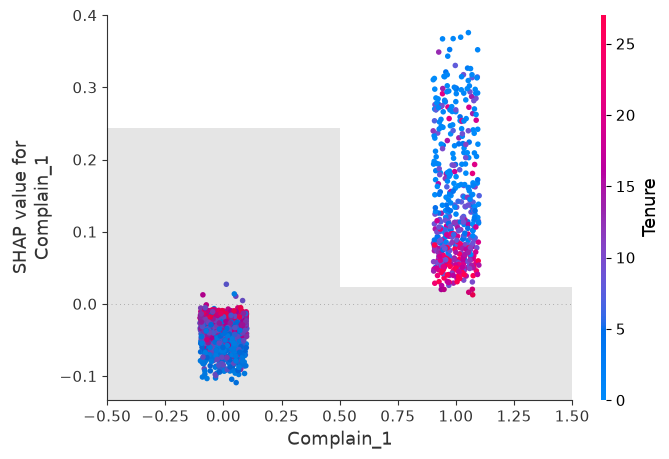

In [108]:
# Dependence Scatter Plot 

X_test_unscaled = encode_step.transform(cap_step.transform(X_test))

sv_asli = shap.Explanation(values=sv.values,
                           base_values=sv.base_values,
                           data=X_test_unscaled,          
                           feature_names=nama_fitur)

shap.plots.scatter(sv_asli[:, 'Complain_1'], color=sv_asli)

Simpan Model 

In [153]:
import joblib

# Menyimpan seluruh pipeline MLP (preprocessing + model)
joblib.dump(tuned_grid['MLP'], 'model_churn.pkl')

# Menyimpan daftar kolom mentah sesuai urutan input
joblib.dump({'num_cols': num_cols, 'cat_cols': cat_cols}, 'kolom_input.pkl')

# Menyimpan background dataset SHAP 
joblib.dump(bg, 'shap_background.pkl')

['shap_background.pkl']